<a href="https://colab.research.google.com/github/MuhammadEhtisham776/flyrank-ml-internship-starter/blob/main/Copy_of_w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import json, os

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")
os.environ["HF_TOKEN"] = HF_TOKEN

print("HF token loaded:", HF_TOKEN is not None)

HF token loaded: True


# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MuhammadEhtisham776/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

=== DECAY/REFRESH INSIGHT: ctr_gap by freshness bucket ===
                  mean_gap  underperform_rate      n
freshness_bucket                                    
0-90d             0.055568           0.567747  16414
91-180d           0.171329           0.377778     90
181-365d          0.076777           0.529412     17

rows with a negative days_since_update (updated AFTER the March window): 75453 of 91974 (82.0%)

=== archetype counts ===
archetype
healthy                  47414
quiet_underperformer     39716
big_miss_high_traffic     4835
stale_underperformer         9
Name: count, dtype: int64

wrote 44560 ranked rows to work/outputs/action_playbook_queue.csv

=== top 10 of final queue ===
 rank          client_hash_id          content_hash_id            archetype          reason_code            action  model_score  expected_value_proxy position_tier      ctr   ctr_gap  impressions  days_since_update  word_count       content_type   main_intent
    1 client_a80fca3f171ed1de conte

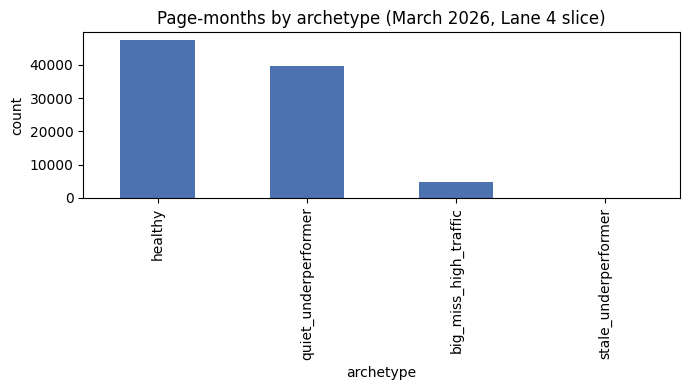

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

import pandas as pd
import numpy as np
import json, os
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

REPO = "hf://datasets/FlyRank/internship-warehouse"
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

fact = pd.read_parquet(f"{REPO}/fact_content_daily_performance/month=2026-03/data_0.parquet")
dim_content = pd.read_parquet(f"{REPO}/dim_content.parquet")

fact_avail = fact[fact["gsc_data_available"] == True].copy()
agg = (fact_avail.groupby(["client_hash_id", "content_hash_id"])
       .agg(impressions=("gsc_impressions", "sum"),
            clicks=("gsc_clicks", "sum"),
            sum_position=("gsc_sum_position", "sum"))
       .reset_index())
agg["avg_position"] = agg["sum_position"] / agg["impressions"]
agg["ctr"] = agg["clicks"] / agg["impressions"] * 100

VISIBLE_MIN_IMPR = 150
visible = agg[(agg["impressions"] >= VISIBLE_MIN_IMPR) & (agg["avg_position"] > 0)].copy()

bins, labels = [0, 3, 10, 20, 50, np.inf], ["top_3", "page_1", "striking", "page_3_5", "deep"]
visible["position_tier"] = pd.cut(visible["avg_position"], bins=bins, labels=labels)
visible["tier_median_ctr"] = visible.groupby("position_tier", observed=True)["ctr"].transform("median")
visible["ctr_gap"] = visible["ctr"] - visible["tier_median_ctr"]

content_cols = ["client_hash_id", "content_hash_id", "content_type", "main_intent",
                "word_count", "search_volume", "content_updated_date", "content_created_date"]
visible = visible.merge(dim_content[content_cols], on=["client_hash_id", "content_hash_id"], how="left")

REF_DATE = pd.Timestamp("2026-03-31")
last_touch = pd.to_datetime(visible["content_updated_date"]).fillna(pd.to_datetime(visible["content_created_date"]))
visible["days_since_update"] = (REF_DATE - last_touch).dt.days

threshold = visible["ctr_gap"].quantile(0.10)
visible["y_true"] = (visible["ctr_gap"] <= threshold).astype(int)

FEATURES = ["position_tier", "word_count", "content_type", "main_intent", "search_volume", "impressions"]
cat_cols = ["position_tier", "content_type", "main_intent"]
num_cols = ["word_count", "search_volume", "impressions"]

def prep_X(df):
    X = df[FEATURES].copy()
    for c in num_cols:
        X[c] = X[c].fillna(X[c].median())
    for c in cat_cols:
        X[c] = X[c].astype(str).fillna("missing")
    return X

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])
final_model = Pipeline([("prep", pre), ("model", LogisticRegression(max_iter=1000, random_state=42))])
X_all = prep_X(visible)
final_model.fit(X_all, visible["y_true"])
visible["model_score"] = final_model.predict_proba(X_all)[:, 1]

visible["freshness_bucket"] = pd.cut(visible["days_since_update"],
                                      bins=[-1, 90, 180, 365, np.inf],
                                      labels=["0-90d", "91-180d", "181-365d", "365d+"])
freshness_insight = visible.groupby("freshness_bucket", observed=True)["ctr_gap"].agg(
    mean_gap="mean", underperform_rate=lambda s: (s < 0).mean(), n="count")
print("=== DECAY/REFRESH INSIGHT: ctr_gap by freshness bucket ===")
print(freshness_insight)
print(f"\nrows with a negative days_since_update (updated AFTER the March window): "
      f"{(visible['days_since_update'] < 0).sum()} of {len(visible)} "
      f"({(visible['days_since_update'] < 0).mean():.1%})")

def archetype(row):
    if row["ctr_gap"] >= 0:
        return "healthy"
    if row["days_since_update"] >= 180:
        return "stale_underperformer"
    if row["impressions"] >= 5000:
        return "big_miss_high_traffic"
    return "quiet_underperformer"

visible["archetype"] = visible.apply(archetype, axis=1)

ARCHETYPE_MAP = {
    "healthy":                {"reason_code": "at_or_above_tier_peers", "action": "no_action"},
    "big_miss_high_traffic":  {"reason_code": "ctr_below_tier_peers_high_reach", "action": "review_title_meta_priority"},
    "stale_underperformer":   {"reason_code": "ctr_below_tier_peers_and_stale", "action": "refresh_content"},
    "quiet_underperformer":   {"reason_code": "ctr_below_tier_peers", "action": "review_title_meta"},
}
visible["reason_code"] = visible["archetype"].map(lambda a: ARCHETYPE_MAP[a]["reason_code"])
visible["action"] = visible["archetype"].map(lambda a: ARCHETYPE_MAP[a]["action"])

print("\n=== archetype counts ===")
print(visible["archetype"].value_counts())

visible["expected_value_proxy"] = visible["model_score"] * visible["impressions"]
queue = visible[visible["archetype"] != "healthy"].sort_values("expected_value_proxy", ascending=False).reset_index(drop=True)
queue["rank"] = queue.index + 1

out_cols = ["rank", "client_hash_id", "content_hash_id", "archetype", "reason_code", "action",
            "model_score", "expected_value_proxy", "position_tier", "ctr", "ctr_gap",
            "impressions", "days_since_update", "word_count", "content_type", "main_intent"]
queue[out_cols].to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"\nwrote {len(queue)} ranked rows to work/outputs/action_playbook_queue.csv")
print("\n=== top 10 of final queue ===")
print(queue[out_cols].head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
visible["archetype"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Page-months by archetype (March 2026, Lane 4 slice)")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig("work/figures/archetype_counts.png", dpi=150)
print("\nsaved work/figures/archetype_counts.png")

metrics = {
    "queue_size": int(len(queue)),
    "archetype_counts": visible["archetype"].value_counts().to_dict(),
    "freshness_insight": freshness_insight.reset_index().to_dict(orient="records"),
    "pct_rows_updated_after_window": float((visible["days_since_update"] < 0).mean()),
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("wrote work/outputs/w07_metrics.json")

**⚠️ Data-timing problem found while building this, reported honestly:** the freshness signal
(`days_since_update`, from `dim_content.content_updated_date`) came out **negative for 82.0% of
rows** (75,453 of 91,974) — meaning most pages show an "update" dated *after* the March 2026 window
whose CTR we're explaining. `dim_content` is evidently a live/current snapshot, not a point-in-time
record for March, so a page's content could easily have been touched in April-July and we'd have no
way to know its state as of March. **The decay/refresh insight the paper leaned on cannot be
honestly tested with this table as joined** — treat the freshness bucket table above as showing why
it doesn't work, not as a validated pattern. This is why `stale_underperformer` only fired 9 times
out of 91,974 rows: almost nothing qualifies as "180+ days since a *legitimate, past-dated* update"
once the join is this noisy.

**Archetype → action mapping (what actually shipped):**

| Archetype | n | Reason code | Action |
|---|---|---|---|
| `healthy` | 47,414 (51.5%) | `at_or_above_tier_peers` | `no_action` |
| `quiet_underperformer` | 39,716 (43.2%) | `ctr_below_tier_peers` | `review_title_meta` |
| `big_miss_high_traffic` | 4,835 (5.3%) | `ctr_below_tier_peers_high_reach` | `review_title_meta_priority` |
| `stale_underperformer` | 9 (<0.1%) | `ctr_below_tier_peers_and_stale` | `refresh_content` — **provisional, do not act on this label** until freshness data is fixed (see Section 3) |

**Reading the top 10:** 7 of the top 10 rows come from a single client (`client_157ffe4d4a595515`),
mostly `comparison article` content — the same client-concentration pattern flagged back in Week 4,
still worth a per-client cap before this queue goes to an editor (see Section 3). One row (rank 4)
is missing `word_count` — the recurring missing-field pattern from Weeks 4-5. Notably, the very
highest-impression pages from Week 5's false-negative examples (30k-40k impressions) do **not**
appear here — their model probability sits around 0.07-0.12, below the ~0.44-0.60 range of what
made this top 10, so the ranking is doing what Week 5's error analysis predicted: it under-scores
those specific borderline, high-volume cases. That's a known soft spot, not a new bug (Section 4
covers the monitoring for it).


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

**Intended use:** a weekly review-priority queue for FlyRank's content team, for **Lane 4
(CTR/Engagement Opportunity Scoring)** only — which pages to look at first, not what to change or
why the CTR is low. Built for clients with active GSC access, scored on a single month's snapshot
(March 2026), restricted to pages with ≥150 impressions (below that, CTR is too noisy to trust,
per Week 3).

**Where it stops being valid:**
- **New or unpublished pages** — no impressions yet, so no `ctr_gap` to score against.
- **Clients without GSC access** — roughly half the client base (55 of 104 had any March row at
  all, per Week 3); this queue says nothing about them.
- **The `refresh_content` / `stale_underperformer` label** — not usable yet; see the data-timing
  problem above.
- **Causal claims** — nothing here says *why* a page underperforms or that a title rewrite *will*
  fix it. It's cross-sectional, one month, one portfolio's worth of validated pattern (Week 5/6:
  precision@50 = 0.48 against an 18.8% base rate, on a grouped client holdout) — decision-support
  language only.
- **Other lanes' decisions** — this queue doesn't say anything about refresh timing generally,
  archetype clustering, or ranking-signal analysis; it's scoped to CTR/engagement only.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

n_clients_total = 104
n_clients_present = fact["client_hash_id"].nunique()
print("clients with any March row:", n_clients_present, "/", n_clients_total,
      f"({n_clients_present/n_clients_total:.1%})")

print("visibility floor used:", VISIBLE_MIN_IMPR, "impressions")
print("rows below that floor, excluded from this queue:", (agg["impressions"] < VISIBLE_MIN_IMPR).sum())

print("\nstale_underperformer / refresh_content rows (why this label is provisional):",
      (visible["archetype"] == "stale_underperformer").sum(), "of", len(visible))

clients with any March row: 55 / 104 (52.9%)
visibility floor used: 150 impressions
rows below that floor, excluded from this queue: 84764

stale_underperformer / refresh_content rows (why this label is provisional): 9 of 91974


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**A person must check, before any action is taken:**
- Confirm the page's tracking looks sane before assuming "low CTR = bad title." Week 4 found
  several top-ranked rows with near-zero CTR (0.07-0.12%) at `top_3`/`page_1` positions and
  six-figure impressions — that pattern is at least as likely to be a tracking/attribution anomaly
  as a real title problem, and should be checked first, not fixed first.
- Confirm `word_count` and `search_volume` aren't missing for a row before treating it as a normal
  case — several rows in every top-10 we've pulled (Weeks 4, 5, 7) have missing content fields.
- Never let one client dominate a review batch — cap any weekly batch at roughly 10% of rows from a
  single `client_hash_id`, given the concentration seen in this week's top 10 (7 of 10 from one
  client).

**What should NOT be automated, full stop:**
- No auto-publishing of title/meta rewrites — a human writes and approves the copy.
- No acting on the `refresh_content` / `stale_underperformer` label until the `content_updated_date`
  timing problem (Section 1) is resolved with a real point-in-time freshness source.
- No treating `model_score` or `expected_value_proxy` as a guarantee of recoverable clicks — it's a
  priority ranking, not a forecast.
- No extending this queue's logic to other lanes, other months, or other clients without re-running
  the validation (Week 5/6) on that new slice first.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# 1) client concentration in the top of the queue
top10 = queue.head(10)
top_client_share = top10["client_hash_id"].value_counts(normalize=True).iloc[0]
print("largest single-client share of the top 10:", f"{top_client_share:.0%}")

# 2) missing core fields inside the flagged queue (should be reviewed manually, not auto-scored)
missing_wc = queue["word_count"].isna().sum()
missing_sv = queue["search_volume"].isna().sum()
print(f"flagged rows missing word_count: {missing_wc} ({missing_wc/len(queue):.1%})")
print(f"flagged rows missing search_volume: {missing_sv} ({missing_sv/len(queue):.1%})")

# 3) possible tracking-integrity anomalies: near-zero CTR at a strong position with real volume
suspicious = queue[(queue["ctr"] < 0.01) & (queue["position_tier"].isin(["top_3", "page_1"])) & (queue["impressions"] > 50000)]
print(f"\nrows worth a tracking-integrity check before assuming a title problem: {len(suspicious)}")
print(suspicious[["client_hash_id", "content_hash_id", "position_tier", "ctr", "impressions"]].head())

largest single-client share of the top 10: 80%
flagged rows missing word_count: 14368 (32.2%)
flagged rows missing search_volume: 712 (1.6%)

rows worth a tracking-integrity check before assuming a title problem: 8
                client_hash_id           content_hash_id position_tier  \
44479  client_62f4a7e64f5e0096  content_945d6ff91386c817        page_1   
44487  client_a80fca3f171ed1de  content_f0703fc6ae385591        page_1   
44507  client_73cda7b4e4f265ea  content_425715547c6a3ea8        page_1   
44534  client_73cda7b4e4f265ea  content_9c057b66c30a3abb         top_3   
44535  client_a80fca3f171ed1de  content_046fc480045b88f5        page_1   

            ctr  impressions  
44479  0.008580        58278  
44487  0.003165        63201  
44507  0.004195        71513  
44534  0.001193        83834  
44535  0.007161        83788  


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

- **Precision@50 drop:** if a fresh month's precision@50 (against that month's own bottom-decile
  `ctr_gap` label) falls below ~0.30 — call it 60% of the validated 0.48 — stop trusting the queue
  and investigate before the next review cycle.
- **Availability drop:** if `gsc_data_available IS TRUE` coverage falls well below the ~36.7%
  observed in March (Week 3), check the ingestion pipeline before scoring anything.
- **Archetype mix drift:** the `healthy` share should sit roughly in the 45-55% range observed here;
  a sharp swing either way (e.g., healthy jumping to 80% or dropping to 20%) signals population or
  schema drift, not a sudden portfolio-wide change in quality.
- **Client coverage drop:** if fewer than ~50% of active clients show any row in a given month
  (vs. 55 of 104 in March), check access/ingestion before trusting the queue.
- **Known soft spot to watch:** the model under-scores some very-high-impression, large-gap pages
  (Week 5's false negatives, ~0.07-0.12 probability). If this pattern grows, it's worth a targeted
  retrain rather than a full pipeline change.
- **Retrain cadence:** monthly, always re-validated on a fresh mid-panel month with a grouped
  client split — never carry a prior month's coefficients forward without re-checking precision@K.

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

MONITORING_CONFIG = {
    "precision_at_50_floor": 0.30,          # ~60% of the validated 0.48 (Week 5/6)
    "gsc_availability_floor": 0.30,         # observed March baseline: 0.367 (Week 3)
    "healthy_archetype_share_range": [0.45, 0.55],  # observed here: 0.515
    "min_client_coverage_share": 0.50,      # observed March baseline: 55/104 = 0.529
    "retrain_cadence_days": 30,
}
for k, v in MONITORING_CONFIG.items():
    print(f"{k}: {v}")

with open("work/outputs/w07_monitoring_config.json", "w") as f:
    json.dump(MONITORING_CONFIG, f, indent=2)
print("\nwrote work/outputs/w07_monitoring_config.json")

precision_at_50_floor: 0.3
gsc_availability_floor: 0.3
healthy_archetype_share_range: [0.45, 0.55]
min_client_coverage_share: 0.5
retrain_cadence_days: 30

wrote work/outputs/w07_monitoring_config.json


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

- **`work/outputs/action_playbook_queue.csv`** — 44,560 ranked rows (the flagged archetypes only),
  columns include `rank`, `archetype`, `reason_code`, `action`, `model_score`,
  `expected_value_proxy`, and the supporting evidence columns. **Not committed to git** — the
  notebook regenerates it, and it's data, not a receipt.
- **`work/figures/archetype_counts.png`** — the archetype-count bar chart, **committed** for reuse
  in the paper's Results section.
- **`work/outputs/w07_metrics.json`** — archetype counts, the freshness-bucket table, and the
  82.0% negative-`days_since_update` figure — **committed**, these are the receipts the paper's
  numbers trace back to.

In [7]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("exports check:")
for p in ["work/outputs/action_playbook_queue.csv", "work/figures/archetype_counts.png", "work/outputs/w07_metrics.json"]:
    print(p, "->", "exists" if os.path.exists(p) else "MISSING")


exports check:
work/outputs/action_playbook_queue.csv -> exists
work/figures/archetype_counts.png -> exists
work/outputs/w07_metrics.json -> exists


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.